In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding, Dropout, LSTM, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings("ignore")
print('ALL assets imported successfully!')

ALL assets imported successfully!


In [2]:
df = pd.read_csv('reviewsAmazon.csv')

#shape of the dataset
print('Shape of the dataset:', df.shape)

#head of the dataset
print("Head of the dataset:")
print(df.head())


Shape of the dataset: (25000, 2)
Head of the dataset:
                                              Review  Sentiment
0  Fast shipping but this product is very cheaply...          1
1  This case takes so long to ship and it's not e...          1
2  Good for not droids. Not good for iPhones. You...          1
3  The cable was not compatible between my macboo...          1
4  The case is nice but did not have a glow light...          1


In [3]:
#checking for null values
print("Null values in each column:")
print(df.isnull().sum())

#droping the null values
df.dropna(inplace=True)

#checking again for null values
print("Null values in each column after dropping:")
print(df.isnull().sum())

Null values in each column:
Review       1
Sentiment    0
dtype: int64
Null values in each column after dropping:
Review       0
Sentiment    0
dtype: int64


In [4]:
#stats summary of the dataset
print('statistical summary of the dataset:')
print(df.describe())

#which i now realise is irrelevent

#so info about the dataset
print('Info about the dataset:')
print(df.info())

statistical summary of the dataset:
          Sentiment
count  24999.000000
mean       2.999920
std        1.414214
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Info about the dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 24999 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     24999 non-null  object
 1   Sentiment  24999 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 585.9+ KB
None


In [5]:
#value count of sentiment column
print('Value count of sentiment column:')
print(df['Sentiment'].value_counts())

Value count of sentiment column:
Sentiment
1    5000
2    5000
3    5000
4    5000
5    4999
Name: count, dtype: int64


In [6]:
#text cleaning and preprocessing
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_reviews(text):

    #removing html tags
    text = re.sub(r'<.*?>', ' ', str(text))

    #removing special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    #converting to lower case
    text = text.lower()

    #tokenization
    tokens = word_tokenize(text)

    #removing stop words
    text = [word for word in tokens if word not in stop_words]
    return ' '.join(text)

#using the function on review text
df['Cleaned_Reviews'] = df['Review'].apply(clean_reviews)

#print the cleaned reviews
print("Cleaned Reviews:")
print(df['Cleaned_Reviews'].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\2004s\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\2004s\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaned Reviews:
0    fast shipping product cheaply made brought gra...
1             case takes long ship even worth dont buy
2    good droids good iphones use features watch ip...
3    cable compatible macbook iphone also connector...
4    case nice glow light disappointed product meet...
Name: Cleaned_Reviews, dtype: object


In [7]:
#tokenization and padding
tokenizer = Tokenizer(num_words=5000)   

#converting the reviews to sequences
reviews_to_list = df['Cleaned_Reviews'].tolist()

#fitting the tokenizer on the reviews
tokenizer.fit_on_texts(reviews_to_list)

#generating sequences
seq = tokenizer.texts_to_sequences(reviews_to_list)

#padding the sequences  
padded_seq = pad_sequences(seq, maxlen=500)

#array of the padded sequences
text_seq = np.array(padded_seq) 

#one hot encoding the labels
labels = pd.get_dummies(df['Sentiment'], prefix='Sentiment')

x = pad_sequences(seq, maxlen=500)
y = labels.values

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)
print("Label columns:", labels.columns.tolist())


Shape of x: (24999, 500)
Shape of y: (24999, 5)
Label columns: ['Sentiment_1', 'Sentiment_2', 'Sentiment_3', 'Sentiment_4', 'Sentiment_5']


In [8]:
#train_test_split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of x_train: (19999, 500)
Shape of x_test: (5000, 500)
Shape of y_train: (19999, 5)
Shape of y_test: (5000, 5)


In [9]:
# Creating a RNN model
max_features = 5000
max_len = x.shape[1]
embedding_dim = 128
num_classes = y.shape[1]

rnn = Sequential(name="Simple_RNN")
rnn.add(Embedding(
    input_dim=max_features,
    output_dim=embedding_dim,
    input_length=max_len
))
rnn.add(SimpleRNN(128, activation='tanh', return_sequences=True))
rnn.add(Dropout(0.3))
rnn.add(SimpleRNN(64, activation='tanh', return_sequences=False))
rnn.add(Dropout(0.3))
rnn.add(Dense(num_classes, activation='softmax'))

rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# build once so summary shows concrete shapes/params
rnn.build(input_shape=(None, max_len))

# printing model summary
rnn.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,573 (2.62 MB)

 Trainable params: 685,573 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#compiling the model
rnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#training the model
history = rnn.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test)
)
print("simple RNN model trained successfully!")
print("Training history:", history.history)
print("score", rnn.evaluate(x_test, y_test))

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 485ms/step - accuracy: 0.2114 - loss: 1.7254 - val_accuracy: 0.1966 - val_loss: 1.6073
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 484ms/step - accuracy: 0.2061 - loss: 1.7081 - val_accuracy: 0.2006 - val_loss: 1.6201
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 75s 480ms/step - accuracy: 0.2011 - loss: 1.6630 - val_accuracy: 0.2050 - val_loss: 1.6115
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 515ms/step - accuracy: 0.2090 - loss: 1.6375 - val_accuracy: 0.1964 - val_loss: 1.6143
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 533ms/step - accuracy: 0.2093 - loss: 1.6224 - val_accuracy: 0.2630 - val_loss: 1.6016
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 522ms/step - accuracy: 0.2327 - loss: 1.5947 - val_accuracy: 0.2194 - val_loss: 1.6572
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 512ms/step - accuracy: 0.3304 - loss: 1.4475 - val_accuracy: 0.3566 - val_loss: 1.3970
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 521ms/step - accuracy: 0.3533 - loss: 1

In [11]:
# LSTM
vocab_size = min(max_features, len(tokenizer.word_index) + 1)
model = Sequential(name="LSTM_Model")
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len,
))

# adding an LSTM layer
model.add(LSTM(150, return_sequences=False))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# adding a ReLU layer
model.add(Dense(50, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# adding the final softmax layer
model.add(Dense(num_classes, activation='softmax'))

model.build(input_shape=(None, max_len))

# printing the model summary
model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       167,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 816,005 (3.11 MB)

 Trainable params: 815,605 (3.11 MB)

 Non-trainable params: 400 (1.56 KB)

In [13]:
#compiling the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#training the model
history = model.fit(
    x_train, y_train,
    batch_size = 64,
    epochs=10,
    validation_data=(x_test, y_test)
)

#printing the training history
print("LSTM model trained successfully!")
print("Training history:", history.history)
print("score", model.evaluate(x_test, y_test))


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 207s 649ms/step - accuracy: 0.3401 - loss: 1.6026 - val_accuracy: 0.3020 - val_loss: 1.5105
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 203s 648ms/step - accuracy: 0.4743 - loss: 1.2200 - val_accuracy: 0.3322 - val_loss: 1.4412
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 645ms/step - accuracy: 0.5425 - loss: 1.0884 - val_accuracy: 0.4066 - val_loss: 1.6027
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 206s 658ms/step - accuracy: 0.6005 - loss: 0.9789 - val_accuracy: 0.4454 - val_loss: 1.3345
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 262s 658ms/step - accuracy: 0.6515 - loss: 0.8816 - val_accuracy: 0.4168 - val_loss: 1.4518
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 201s 642ms/step - accuracy: 0.6899 - loss: 0.7874 - val_accuracy: 0.4312 - val_loss: 1.5691
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 196s 625ms/step - accuracy: 0.7344 - loss: 0.6939 - val_accuracy: 0.4402 - val_loss: 1.7851
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 634ms/step - accuracy: 0.7664 -

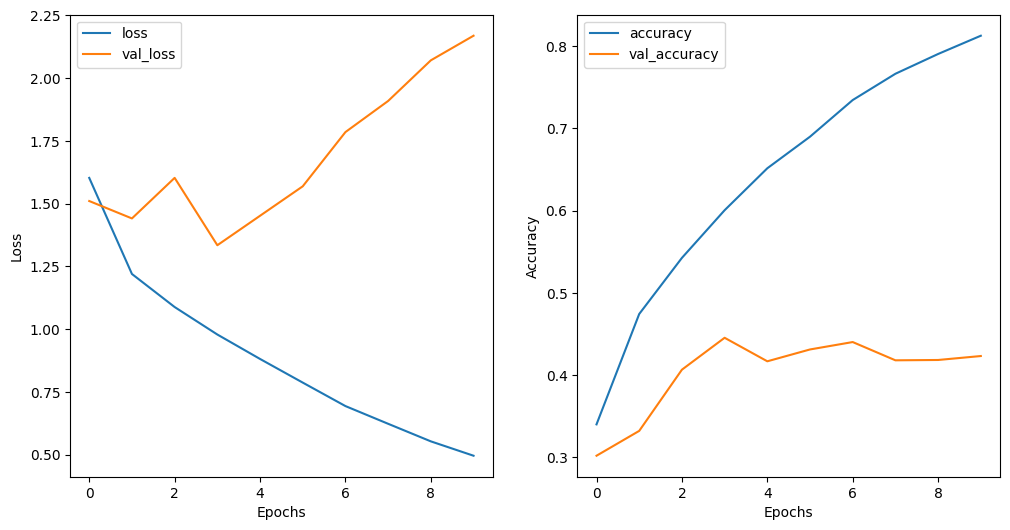

In [16]:
# plotting the history
metrics = history.history
plt.figure(figsize=(12,6))

# plotting training and validation losses
plt.subplot(1, 2, 1)
plt.plot(history.epoch, metrics['loss'])
plt.plot(history.epoch, metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')

# plotting training and validation accuracies
plt.subplot(1, 2, 2)
plt.plot(history.epoch, metrics['accuracy'])
plt.plot(history.epoch, metrics['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()


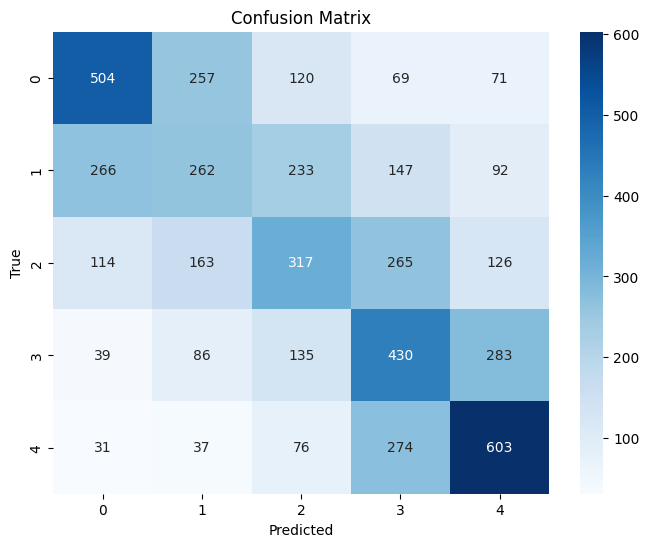

In [18]:
# confusion matrix
y_true = np.argmax(y_test, axis=1)

y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
cm = tf.math.confusion_matrix(y_true, y_pred).numpy()

# plotting the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [19]:
from sklearn.metrics import classification_report
report_chart = classification_report(y_true, y_pred, target_names=labels.columns)
print("Classification Report:")
print(report_chart)

Classification Report:
              precision    recall  f1-score   support

 Sentiment_1       0.53      0.49      0.51      1021
 Sentiment_2       0.33      0.26      0.29      1000
 Sentiment_3       0.36      0.32      0.34       985
 Sentiment_4       0.36      0.44      0.40       973
 Sentiment_5       0.51      0.59      0.55      1021

    accuracy                           0.42      5000
   macro avg       0.42      0.42      0.42      5000
weighted avg       0.42      0.42      0.42      5000



In [21]:
#testing the model on new reviews
def predict_sentiment(review):
    cleaned_review = clean_reviews(review)
    seq = tokenizer.texts_to_sequences([cleaned_review])
    padded_seq = pad_sequences(seq, maxlen=500)
    prediction = model.predict(padded_seq, verbose=0)
    predicted_label = labels.columns[np.argmax(prediction)]
    return predicted_label

#testing the function with a new review
new_review = "This product is amazing! I love it and would highly recommend it to everyone."
predicted_sentiment = predict_sentiment(new_review)

print(f"Review: {new_review}")
print(f"Predicted Sentiment: {predicted_sentiment}")

another = "the product was okay-ish, not the best but not the worst either."
predicted_sentiment_another = predict_sentiment(another)
print(f"Review: {another}")
print(f"Predicted Sentiment: {predicted_sentiment_another}")


Review: This product is amazing! I love it and would highly recommend it to everyone.
Predicted Sentiment: Sentiment_5
Review: the product was okay-ish, not the best but not the worst either.
Predicted Sentiment: Sentiment_3
